# Brain - ANN RSA Gradient analysis

In [1]:
import pandas as pd
import numpy as np
from lstnn.parcellation import Parcellation
import seaborn as sns
import matplotlib.pyplot as plt

# parameters
pe_desc = "2dpe"
fmethod = "crossnobis" # "crossnobis"
amethod = "euclidean" #  "euclidean"
cmethod = "corr" 
epoch = 4000
n_perms = 10000
atlas = "Glasser"

if atlas == "Glasser":
    cortex = 'Glasser'
    cortex_res = None
    scale = 1
elif atlas == "Schaefer":
    cortex = 'Schaefer'
    cortex_res = 400
    scale = 1

parc = Parcellation(cortex=cortex, cortex_res=cortex_res, scale=scale)

df_list = []
in_file = f"/home/lukeh/projects/LSTNN/results/model_comparison/group_atlas-{atlas}/pe-{pe_desc}"
in_file += f"_fmethod-{fmethod}_amethod-{amethod}_cmethod-{cmethod}"
in_file += f"_epoch-{epoch}_nperms-{n_perms}"

df = pd.read_csv(in_file+"_stats.csv")
df.head()

,stat,permutation,compare_method,model,parcel,it,pe,fmethod,cmethod,amethod,epoch,p_FDR,percentile,network
0,0.015285,False,corr,pe_layer0,HIP-rh,0,2dpe,crossnobis,corr,euclidean,4000,1.0,0.7336,NaN
1,0.029015,False,corr,pe_layer1,HIP-rh,0,2dpe,crossnobis,corr,euclidean,4000,1.0,0.8654,NaN
2,-0.005313,False,corr,pe_layer2,HIP-rh,0,2dpe,crossnobis,corr,euclidean,4000,1.0,0.4318,NaN
3,0.014045,False,corr,pe_layer3,HIP-rh,0,2dpe,crossnobis,corr,euclidean,4000,1.0,0.7065,NaN
4,0.015040,False,corr,pe_avg,HIP-rh,0,2dpe,crossnobis,corr,euclidean,4000,1.0,0.6997,NaN


# Surface plot code

# Load Margulies gradients and visualise

In [2]:
from neuromaps.datasets import fetch_annotation
from netneurotools import datasets as nntdata
from neuromaps.parcellate import Parcellater
from neuromaps import stats

glasser = nntdata.fetch_mmpall("fslr32k", data_dir="../data/neuromaps/")
nm_parc = Parcellater(glasser, 'fsLR')
n_gradients = 2
gradients = np.zeros((360, n_gradients))
for i in range(1, n_gradients+1):
    g = fetch_annotation(source='margulies2016', desc=f"fcgradient0{i}", space='fsLR', den='32k', data_dir="../data/neuromaps/", verbose=False)
    gradients[:, i-1] = nm_parc.fit_transform(g, 'fsLR')


pixdim[1,2,3] should be non-zero; setting 0 dims to 1


1.6 -1.6


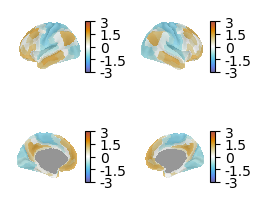

2.4 -2.4


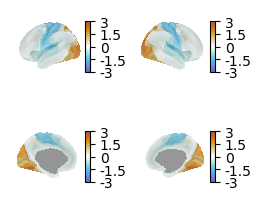

In [3]:
from scipy.stats import zscore
import cmasher as cmr
from lstnn.plotting import pub_surf_plot_contours, pub_surf_plot, get_cropped_img
save = False
plot = True
cmap = cmr.prinsenvlag_r

plot_data = np.zeros((4, parc.n_parcels))


for g in range(n_gradients):
    plot_data = np.zeros((parc.n_parcels))
    data = gradients[:, g].copy()
    z_data = zscore(data)
    plot_data[16::] = z_data
    
    vmax = np.floor(np.max(abs(plot_data))*10)/10
    vmin = vmax*-1
    print(vmax, vmin)

    vmax = 3.0
    vmin = vmax*-1

    if save:
        pub_surf_plot(plot_data, parc.file, save=f"../figures/brain_plots/Gradient_{g}", 
                    size=(2.5, 2.2), thresh=0.000001, cmap=cmap, vmin=vmin, vmax=vmax)
    if plot:
        pub_surf_plot(plot_data, parc.file, save=None, size=(2.5, 2.2), thresh=0.000001, cmap=cmap, vmin=vmin, vmax=vmax)

In [ ]:
stats.compare_images?

In [4]:
from neuromaps import nulls
from neuromaps import stats

pe ="2dpe"
n_perm = 10000
results = []
for g in range(n_gradients):
    rotated = nulls.alexander_bloch(gradients[:, g], atlas="fsLR", density='32k', n_perm=n_perm, seed=42, parcellation=glasser)
    for model in ["mlp"]:
        for layer in [0, 1, 2, 3]:
            data = df.loc[(df.pe == pe) 
                        & (df.model == model+"_layer"+str(layer))
                        & (df.network.notna()), "stat"].values
            corr, pval, null_corrs = stats.compare_images(gradients[:, g], data,
                                                          nulls=rotated, return_nulls=True)
            res = pd.DataFrame()
            res["gradient"] = [g+1]
            res["layer"] = layer
            res["model"] = model
            res["pe"] = pe
            res["n_perms"] = n_perm
            res["r"] = corr
            res["p"] = pval
            res["permutation"] = False
            results.append(res)

            res = pd.DataFrame()
            res["r"] = null_corrs
            res["permutation"] = True
            res["gradient"] = g+1
            res["layer"] = layer
            res["model"] = model
            res["pe"] = pe
            res["n_perms"] = n_perm
            results.append(res)

results = pd.concat(results)

In [5]:
from pingouin import multicomp
for gradient in range(1, 3):
    a = results.loc[(results.permutation == False) 
                    & (results.gradient == gradient)]
    reject, p_corrected = multicomp(a.p.values, method="fdr_by")
    results.loc[(results.permutation == False) 
                    & (results.gradient == gradient),
                    "p_adj"] = p_corrected
display(results.loc[results.permutation == False])

,gradient,layer,model,pe,n_perms,r,p,permutation,p_adj
0,1,0,mlp,2dpe,10000,0.101276,0.516648,False,1.000000
0,1,1,mlp,2dpe,10000,-0.111116,0.422258,False,1.000000
0,1,2,mlp,2dpe,10000,0.060801,0.546545,False,1.000000
0,1,3,mlp,2dpe,10000,0.329496,0.001200,False,0.009999
0,2,0,mlp,2dpe,10000,0.584922,0.000100,False,0.000833
0,2,1,mlp,2dpe,10000,0.322989,0.048395,False,0.134431
0,2,2,mlp,2dpe,10000,-0.017296,0.875312,False,1.000000
0,2,3,mlp,2dpe,10000,-0.207377,0.016498,False,0.068743


In [9]:
display(results.loc[results.p_adj < 0.05])

,gradient,layer,model,pe,n_perms,r,p,permutation,p_adj
0,1,3,mlp,2dpe,10000,0.329496,0.0012,False,0.009999
0,2,0,mlp,2dpe,10000,0.584922,0.0001,False,0.000833


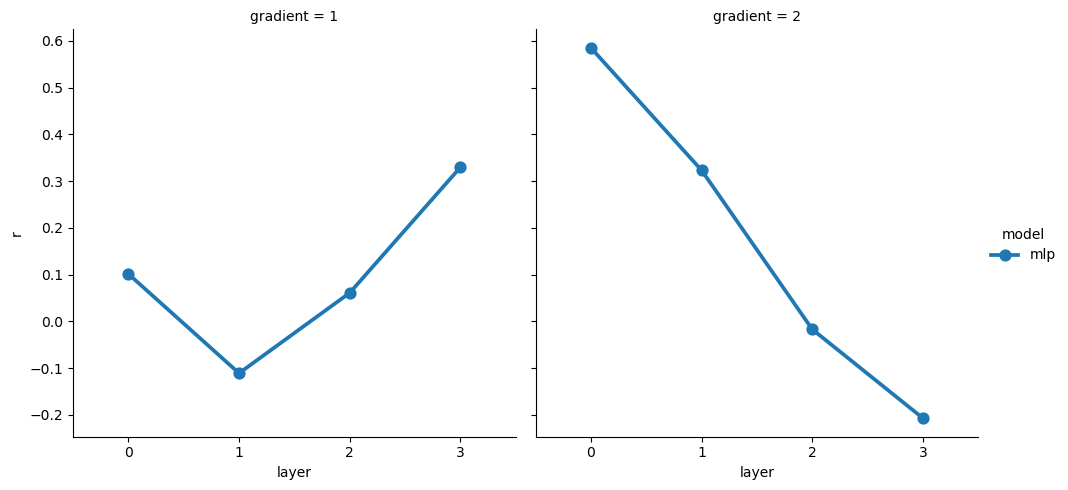

In [ ]:
data = results.loc[results.permutation==False]
sns.catplot(data=data, x="layer", y="r", hue="model", col="gradient", kind="point")

# Plot gradients and permutation tests across layers
## Brain plot

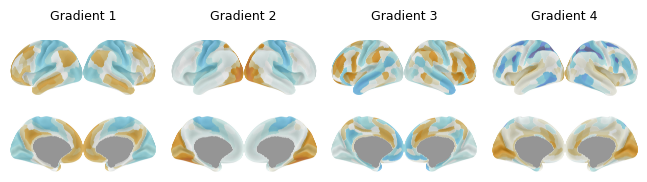

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from lstnn.plotting import get_cropped_img
plt.rcParams['svg.fonttype'] = 'none'

# gridspec inside gridspec
fig = plt.figure(figsize=(8.1, 2))

# rows
rows = gridspec.GridSpec(2, 1, figure=fig, hspace=0, wspace=0, height_ratios=[0.01, 0.495*2])

# create gridspec between brains and scatter plot
cols = gridspec.GridSpecFromSubplotSpec(1, 4, subplot_spec=rows[0], hspace=0, wspace=0.1)
for g in range(4):
    ax = fig.add_subplot(cols[g])
    ax.set_title("Gradient "+str(g+1), fontsize=9)
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_xticks([])
    ax.set_yticks([])
    sns.despine(left=True, bottom=True, ax=ax)

cols = gridspec.GridSpecFromSubplotSpec(1, 4, subplot_spec=rows[1], hspace=0, wspace=0.1)

count = 0
for g in range(0, 4):
    brain_grid = gridspec.GridSpecFromSubplotSpec(2, 2,
                                                  subplot_spec=cols[count],
                                                  hspace=0, wspace=0)
    b_count = 0
    for view in ['lateral', 'medial']:
        for hemi in ['left', 'right']:

            # get image
            img = plt.imread(
                f"../figures/brain_plots/Gradient_{g}_{hemi}_{view}.jpeg")
            img_cropped = get_cropped_img(img,
                                          x_start_buffer=0,
                                          x_finish_buffer=0,
                                          y_start_buffer=0,
                                          y_finish_buffer=0)

            # get ax
            ax = fig.add_subplot(brain_grid[b_count])
            ax.set_xticklabels([])
            ax.set_yticklabels([])
            ax.set_xticks([])
            ax.set_yticks([])
            ax.imshow(img_cropped, aspect='equal', rasterized=True)
            sns.despine(left=True, bottom=True, ax=ax)
            b_count = b_count+1
    count = count+1

plt.savefig("../figures/Gradient_brains.svg", dpi=1200)
plt.show()

In [ ]:
37/49

0.7551020408163265

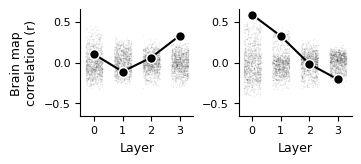

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.rcParams['svg.fonttype'] = 'none'
fig, axs = plt.subplot_mosaic("""
                              AB
                              """,
                              figsize=(4.0*0.875, 1.8*.85),
                              constrained_layout=True)

# line plots
for g, ax_label in zip([1, 2],["A", "B"]):
    ax = axs[ax_label]

    a = results.loc[(results.permutation == True) & (results.gradient == g)]

    # for plotting - randomly sample so that illustrator will load the data...
    a = a.groupby(["gradient", "layer", "model"]).sample(1000)
    sns.stripplot(a, x="layer", y="r", alpha=0.08, dodge=True, 
                    jitter=0.3, color="k", size=1, legend=False, ax=ax)

    mlp = results.loc[(results.permutation == False) 
                      & (results.gradient == g)
                      & (results.model=="mlp"), "r"].values
    ax.plot([0, 1, 2, 3], mlp, color='k', marker='o', markeredgecolor='w', zorder=10, markersize=7)

    ax.tick_params(axis='both', which='major', labelsize=8)
    ax.set_ylabel("", fontsize=9)
    ax.set_xlabel("Layer", fontsize=9)
    ax.set_ylim([-0.65, 0.65])
    if g==1:
        ax.set_ylabel("Brain map\ncorrelation (r)", fontsize=9)
    else:
        ax.set_ylabel("", fontsize=9)
    sns.despine(ax=ax)

plt.savefig(f"../figures/gradient_plot.svg", dpi=600, bbox_inches='tight')
plt.show()

In [ ]:
mlp

array([], dtype=float64)